/var/folders/yp/078pyxw11mq6g7sd_2ty18z80000gn/T/ipykernel_2398/2898187320.py:1: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit import QuantumCircuit



FOUR BELL STATES


BELL STATE : Phi+

QUANTUM CIRCUIT
--------------------------------------------------------------------------------
     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘

MEASUREMENT RESULTS
--------------------------------------------------------------------------------
00 : 515
01 : 0
10 : 0
11 : 509


BELL STATE : Phi-

QUANTUM CIRCUIT
--------------------------------------------------------------------------------
     ┌───┐     ┌───┐
q_0: ┤ H ├──■──┤ Z ├
     └───┘┌─┴─┐└───┘
q_1: ─────┤ X ├─────
          └───┘     

MEASUREMENT RESULTS
--------------------------------------------------------------------------------
00 : 520
01 : 0
10 : 0
11 : 504


BELL STATE : Psi+

QUANTUM CIRCUIT
--------------------------------------------------------------------------------
     ┌───┐          
q_0: ┤ H ├──■───────
     └───┘┌─┴─┐┌───┐
q_1: ─────┤ X ├┤ X ├
          └───┘└───┘

MEASUREMENT RESULTS
-------------------------------------------------

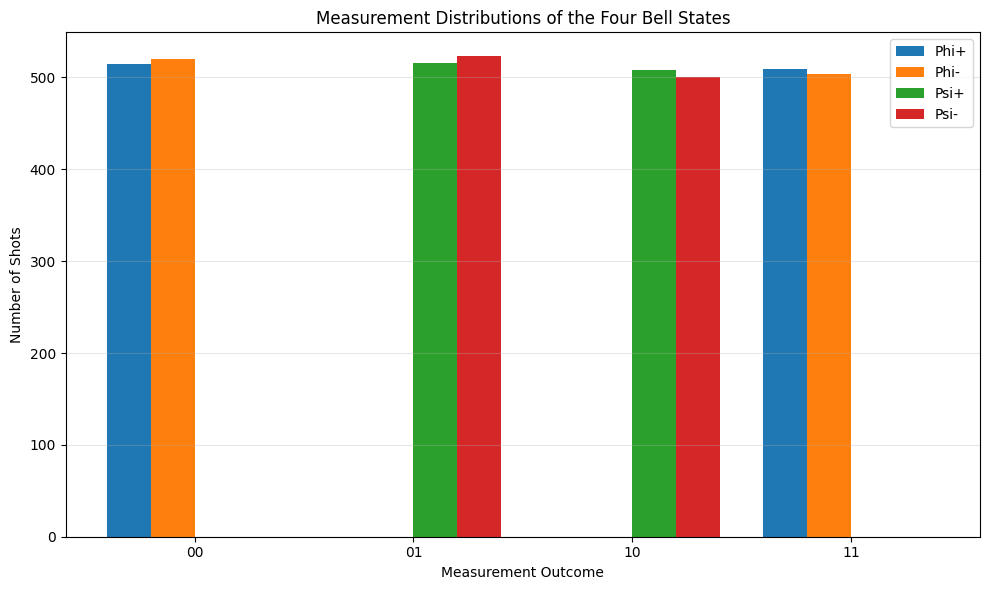

In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
import numpy as np
import matplotlib.pyplot as plt

SHOTS = 1024
SEED = 42

def create_bell_state(state_name):

    qc = QuantumCircuit(2)

    if state_name == "Phi+":

        qc.h(0)
        qc.cx(0, 1)

    elif state_name == "Phi-":

        qc.h(0)
        qc.cx(0, 1)
        qc.z(0)

    elif state_name == "Psi+":

        qc.h(0)
        qc.cx(0, 1)
        qc.x(1)

    elif state_name == "Psi-":

        qc.h(0)
        qc.cx(0, 1)
        qc.x(1)
        qc.z(0)

    return qc


bell_states = [
    "Phi+",
    "Phi-",
    "Psi+",
    "Psi-"
]

labels = [
    "00",
    "01",
    "10",
    "11"
]

rng = np.random.default_rng(SEED)

all_counts = {}

print("\nFOUR BELL STATES")
print("=" * 80)

for bell in bell_states:

    qc = create_bell_state(bell)

    state = Statevector.from_instruction(qc)

    probabilities = state.probabilities()

    samples = rng.choice(
        np.arange(4),
        size=SHOTS,
        p=probabilities
    )

    counts = np.bincount(
        samples,
        minlength=4
    )

    all_counts[bell] = counts

    print("\n")
    print("=" * 80)
    print(f"BELL STATE : {bell}")
    print("=" * 80)

    print("\nQUANTUM CIRCUIT")
    print("-" * 80)
    print(qc.draw())

    print("\nMEASUREMENT RESULTS")
    print("-" * 80)

    for label, count in zip(labels, counts):
        print(f"{label} : {count}")

print("\n")
print("=" * 80)
print("MEASUREMENT DISTRIBUTION TABLE")
print("=" * 80)

print(
    f"{'Bell State':<15}"
    f"{'00':<12}"
    f"{'01':<12}"
    f"{'10':<12}"
    f"{'11':<12}"
)

print("-" * 80)

for bell in bell_states:

    counts = all_counts[bell]

    print(
        f"{bell:<15}"
        f"{counts[0]:<12}"
        f"{counts[1]:<12}"
        f"{counts[2]:<12}"
        f"{counts[3]:<12}"
    )

print("\nTHEORETICAL PATTERN")
print("-" * 80)

print("Phi+  -> 00 and 11")
print("Phi-  -> 00 and 11")
print("Psi+  -> 01 and 10")
print("Psi-  -> 01 and 10")

fig, ax = plt.subplots(
    figsize=(10, 6)
)

x = np.arange(4)

width = 0.2

for i, bell in enumerate(bell_states):

    ax.bar(
        x + (i - 1.5) * width,
        all_counts[bell],
        width,
        label=bell
    )

ax.set_title(
    "Measurement Distributions of the Four Bell States"
)

ax.set_xlabel(
    "Measurement Outcome"
)

ax.set_ylabel(
    "Number of Shots"
)

ax.set_xticks(x)
ax.set_xticklabels(labels)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()
